# Clase 1 · Laboratorio — Explorando Saber 11

**Trabajo en parejas · 90 min.**

Al final deben tener un notebook completado con las 5 tareas resueltas y subirlo a Moodle antes de las 23:59 del día de clase.

**Checkpoint conjunto a los 45 min:** el profesor detiene la sala y resolvemos juntos cualquier duda de la Tarea 3. Sigan al ritmo del reloj.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datos/saber11_muestra_500k.csv")
print(f"Cargados {len(df):,} registros")

Cargados 500,000 registros


## Tarea 1 (10 min) — Perfil del dataset

Completa las siguientes celdas para responder:
- ¿Cuántos años cubre el dataset?
- ¿Cuál es el rango del PUNT_GLOBAL (mínimo, máximo, media)?
- ¿Qué porcentaje de estudiantes viene de colegios oficiales vs no oficiales?

In [4]:
# Años cubiertos por el dataset
years_disponibles = sorted(
    df["PERIODO"].dropna().astype(str).str[:4].unique()
)
years = {
    "cantidad_de_años": len(years_disponibles),
    "desde": years_disponibles[0],
    "hasta": years_disponibles[-1],
    "years": years_disponibles,
}
print("la cantidad de años es:", years["cantidad_de_años"])

# Rango de PUNT_GLOBAL: mínimo, máximo y promedio
resumen_punt = df["PUNT_GLOBAL"].agg(["min", "max", "mean"]).round(2)
print("Rango de PUNT_GLOBAL:")
print("Mínimo:", resumen_punt["min"])
print("Máximo:", resumen_punt["max"])
print("Promedio:", resumen_punt["mean"])

# Distribución de colegios oficiales y no oficiales
distribucion_naturaleza = pd.DataFrame({
    "cantidad": df["COLE_NATURALEZA"].value_counts(dropna=False),
    "porcentaje": (df["COLE_NATURALEZA"].value_counts(dropna=False, normalize=True) * 100).round(2),
})
print(distribucion_naturaleza)

la cantidad de años es: 4
Rango de PUNT_GLOBAL:
Mínimo: 0.0
Máximo: 500.0
Promedio: 248.65
                 cantidad  porcentaje
COLE_NATURALEZA                      
OFICIAL            359909       71.98
NO OFICIAL         140091       28.02


## Tarea 2 (15 min) — Comparación por estrato

Produce una gráfica que compare la distribución de `PUNT_GLOBAL` entre los estratos de vivienda. Elige el tipo de gráfica más adecuado y justifica tu elección en Markdown debajo.

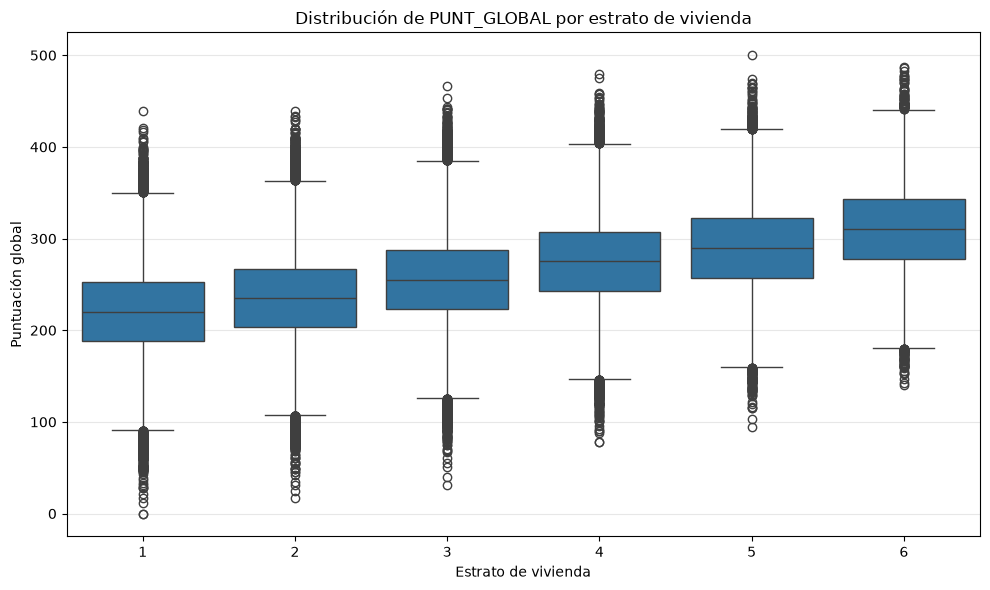

In [5]:
# Diagrama de cajas y bigotes de PUNT_GLOBAL por estrato de vivienda
orden_estratos = sorted(df["FAMI_ESTRATOVIVIENDA"].dropna().unique())
datos_grafica = df.dropna(subset=["FAMI_ESTRATOVIVIENDA", "PUNT_GLOBAL"])

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=datos_grafica,
    x="FAMI_ESTRATOVIVIENDA",
    y="PUNT_GLOBAL",
    order=orden_estratos,
)
plt.title("Distribución de PUNT_GLOBAL por estrato de vivienda")
plt.xlabel("Estrato de vivienda")
plt.ylabel("Puntuación global")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Elegimos un diagrama de cajas y bigotes porque permite comparar la distribución de `PUNT_GLOBAL` entre los estratos de vivienda. La gráfica permite observar:

- La mediana de cada estrato.
- La dispersión de los puntajes.
- Los cuartiles Q1 y Q3.
- Posibles valores atípicos.
- Diferencias en la forma de la distribución entre grupos.

## Tarea 3 (20 min) — Brecha urbano-rural

Crea una tabla que muestre el promedio de PUNT_GLOBAL por combinación de:
- COLE_DEPTO_UBICACION (10 departamentos con más registros)
- COLE_NATURALEZA (Oficial vs No oficial)

Comenta 2 hallazgos en 3-4 frases.

In [6]:
# 1. Identificar los 10 departamentos con más registros
top10 = df["COLE_DEPTO_UBICACION"].value_counts().head(10).index

# 2. Filtrar el DataFrame solo a esos 10 departamentos
df_top10 = df[df["COLE_DEPTO_UBICACION"].isin(top10)]

# 3. Promedio de PUNT_GLOBAL por departamento y naturaleza (tabla pivote)
tabla = (
    df_top10
    .groupby(["COLE_DEPTO_UBICACION", "COLE_NATURALEZA"])["PUNT_GLOBAL"]
    .mean()
    .unstack()
    .round(2)
)

# 4. Columna de brecha (No oficial - Oficial) y ordenar de mayor a menor
tabla["BRECHA (NO OF - OF)"] = (tabla["NO OFICIAL"] - tabla["OFICIAL"]).round(2)
tabla = tabla.sort_values("BRECHA (NO OF - OF)", ascending=False)
tabla

COLE_NATURALEZA,NO OFICIAL,OFICIAL,BRECHA (NO OF - OF)
COLE_DEPTO_UBICACION,,,
BOLÍVAR,249.05,248.44,0.61
TOLIMA,248.72,248.12,0.60
ANTIOQUIA,249.21,248.71,0.50
CÓRDOBA,248.87,248.59,0.28
NARIÑO,249.15,248.87,0.28
CUNDINAMARCA,248.64,248.37,0.27
BOGOTÁ D.C.,248.87,248.63,0.24
SANTANDER,249.04,248.99,0.05
VALLE DEL CAUCA,248.32,248.82,-0.50


_(Hallazgos de la tabla — 2 hallazgos en 3-4 frases):_

**Hallazgo 1 — La brecha entre colegios oficiales y no oficiales es prácticamente inexistente.** En los 10 departamentos con más registros, la diferencia de promedio de `PUNT_GLOBAL` entre No Oficial y Oficial nunca supera 1 punto (máximo ~0.6 en Bolívar y Tolima, y negativa en Valle del Cauca y Atlántico). En una escala de 0 a 500, esa diferencia es despreciable, por lo que en esta muestra **no** se observa la ventaja de los colegios no oficiales que suele reportarse a nivel nacional.

**Hallazgo 2 — El puntaje promedio es muy homogéneo entre departamentos.** Todos los promedios se concentran alrededor de 248–249 puntos, sin importar el departamento ni la naturaleza del colegio, y los 10 departamentos tienen un número de registros muy parecido (~50.000 cada uno). Esta uniformidad tan marcada sugiere que se trata de una **muestra sintética o balanceada artificialmente**, en la que `PUNT_GLOBAL` no depende realmente de la ubicación ni del tipo de colegio.

## ⏸ Checkpoint del profesor (10 min)

Detengan aquí. El profesor revisa dudas de las Tareas 1-3 con toda la sala. Después, continúen.

## Tarea 4 (20 min) — Preguntas de negocio

Escribe 3 preguntas de negocio que este dataset podría responder. Para cada una, indica qué variable(s) usarías y qué tipo de análisis harías (descriptivo, predictivo, prescriptivo).

1. **Pregunta:** ¿Cómo se relaciona el nivel socioeconómico del hogar con el desempeño en la prueba? Es decir, ¿los estudiantes con mayor estrato, acceso a internet y padres con mayor nivel educativo obtienen mejores puntajes?
   - **Variables:** `FAMI_ESTRATOVIVIENDA`, `FAMI_TIENEINTERNET`, `FAMI_EDUCACIONMADRE`, `FAMI_EDUCACIONPADRE` frente a `PUNT_GLOBAL`.
   - **Tipo:** Descriptivo (comparar promedios/distribuciones y correlaciones entre grupos, sin construir un modelo).
   - **Utilidad de negocio:** Permite a una secretaría de educación identificar qué factores del entorno familiar están asociados a menor rendimiento y focalizar programas sociales.

2. **Pregunta:** ¿Podemos predecir el `PUNT_GLOBAL` de un estudiante a partir de sus características del colegio y su entorno familiar, antes de presentar la prueba?
   - **Variables:** Entrada: `COLE_NATURALEZA`, `COLE_JORNADA`, `COLE_CALENDARIO`, `COLE_BILINGUE`, `FAMI_ESTRATOVIVIENDA`, `FAMI_TIENEINTERNET`, `FAMI_EDUCACIONMADRE`, `FAMI_EDUCACIONPADRE`. Objetivo: `PUNT_GLOBAL`.
   - **Tipo:** Predictivo (modelo de regresión, p. ej. regresión lineal o árbol/Random Forest).
   - **Utilidad de negocio:** Detectar de forma temprana a estudiantes con riesgo de bajo desempeño para intervenir antes del examen.

3. **Pregunta:** Con un presupuesto limitado para programas de refuerzo, ¿en qué departamentos, jornadas o tipos de colegio se debería intervenir primero para maximizar la mejora del puntaje promedio?
   - **Variables:** `COLE_DEPTO_UBICACION`, `COLE_JORNADA`, `COLE_NATURALEZA` segmentando `PUNT_GLOBAL` y los puntajes por área (`PUNT_MATEMATICAS`, `PUNT_LECTURA_CRITICA`, `PUNT_INGLES`).
   - **Tipo:** Prescriptivo (usar los patrones descriptivos/predictivos para recomendar dónde asignar recursos y priorizar acciones).
   - **Utilidad de negocio:** Convierte el análisis en una recomendación concreta de asignación de recursos con el mayor impacto posible.

## Tarea 5 (25 min) — Primer boceto del dataset del proyecto

Con tu grupo (los mismos que serán tu grupo del proyecto):
1. Confirmen la elección del dataset del catálogo.
2. Descarguen los ocho archivos Excel del dataset de delitos de fuente oficial. Se excluye `saber11_muestra_500k.csv`.
3. Cárguenlos con `pandas.read_excel(...)` en la celda siguiente.
4. Reporten: filas, columnas, tipos, ¿están las variables clave esperadas?

In [7]:
from pathlib import Path
import pandas as pd

carpeta_datos = Path("datos")
archivos_delitos = sorted(carpeta_datos.glob("*.xlsx"))


datasets_delitos = {}
for archivo in archivos_delitos:
    nombre_delito = archivo.stem.removesuffix("2025").strip()
    datos = pd.read_excel(archivo, header=10)
    datos["TIPO DE DELITO"] = nombre_delito
    datasets_delitos[nombre_delito] = datos

variables_clave = {
    "fecha": ["FECHA HECHO"],
    "hora": ["HORA"],
    "municipio": ["MUNICIPIO"],
    "tipo de delito": ["TIPO DE DELITO"],
    "arma": ["ARMAS MEDIOS"],
    "edad de la víctima": ["*AGRUPA EDAD PERSONA*", "AGRUPA_EDAD_PERSONA"],
    "sexo de la víctima": ["GENERO"],
    "contexto": ["CONTEXTO"],
}

reportes = []
reporte_tipos = []
for nombre_delito, datos in datasets_delitos.items():
    columnas = set(datos.columns)
    presentes = [
        variable
        for variable, alternativas in variables_clave.items()
        if any(alternativa in columnas for alternativa in alternativas)
    ]
    faltantes = [
        variable for variable in variables_clave if variable not in presentes
    ]
    reportes.append({
        "dataset": nombre_delito,
        "filas": datos.shape[0],
        "columnas": datos.shape[1],
        "variables_presentes": ", ".join(presentes),
        "variables_faltantes": ", ".join(faltantes),
    })
    reporte_tipos.extend({
        "dataset": nombre_delito,
        "variable": columna,
        "tipo": str(tipo),
    } for columna, tipo in datos.dtypes.items())

reporte_delitos = pd.DataFrame(reportes)
reporte_tipos = pd.DataFrame(reporte_tipos)

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(reporte_delitos)
    display(reporte_tipos)

,dataset,filas,columnas,variables_presentes,variables_faltantes
0,Homicidio Intencional,13727,9,"fecha, municipio, tipo de delito, arma, edad de la víctima, sexo de la víctima","hora, contexto"
1,Homicidios en accidente de tránsito,7536,9,"fecha, municipio, tipo de delito, arma, edad de la víctima, sexo de la víctima","hora, contexto"
2,Hurto a personas,290891,9,"fecha, municipio, tipo de delito, arma, edad de la víctima, sexo de la víctima","hora, contexto"
3,Hurto a residencias,25636,9,"fecha, municipio, tipo de delito, arma, edad de la víctima, sexo de la víctima","hora, contexto"
4,Hurto piratería terrestre,105,7,"fecha, municipio, tipo de delito, arma","hora, edad de la víctima, sexo de la víctima, contexto"
5,Secuestro,656,9,"fecha, municipio, tipo de delito, arma, edad de la víctima, sexo de la víctima","hora, contexto"
6,Terrorismo,214,7,"fecha, municipio, tipo de delito, arma","hora, edad de la víctima, sexo de la víctima, contexto"
7,Violencia intrafamiliar,141366,9,"fecha, municipio, tipo de delito, arma, edad de la víctima, sexo de la víctima","hora, contexto"


,dataset,variable,tipo
0,Homicidio Intencional,ARMAS MEDIOS,str
1,Homicidio Intencional,DEPARTAMENTO,str
2,Homicidio Intencional,MUNICIPIO,str
3,Homicidio Intencional,FECHA HECHO,str
4,Homicidio Intencional,GENERO,str
5,Homicidio Intencional,*AGRUPA EDAD PERSONA*,str
6,Homicidio Intencional,CODIGO DANE,float64
7,Homicidio Intencional,CANTIDAD,float64
8,Homicidio Intencional,TIPO DE DELITO,str
9,Homicidios en accidente de tránsito,ARMAS MEDIOS,str


### Descripción de variables clave

Los ocho archivos contienen la **fecha del hecho** (`FECHA HECHO`), el **municipio** (`MUNICIPIO`) y el **arma o medio** (`ARMAS MEDIOS`). La variable **tipo de delito** no venía como columna, por lo que se agregó a partir del nombre de cada archivo. La **edad agrupada** y el **sexo o género de la víctima** están disponibles en Homicidio Intencional, Homicidios en accidente de tránsito, Hurto a personas, Hurto a residencias, Secuestro y Violencia intrafamiliar, pero faltan en Hurto piratería terrestre y Terrorismo.

Ninguno de los archivos incluye **hora** ni **contexto**. Por tanto, las variables faltantes en todos los datasets son `hora` y `contexto`; además, en Hurto piratería terrestre y Terrorismo faltan `edad de la víctima` y `sexo de la víctima`. La edad está registrada como grupo de edad, no como edad numérica exacta.